# Consigna
Trabajaremos con el dataset disponible en campus el cual contiene los siguientes datos sobre clientes:

1. purchase_freq_month — frecuencia de compras por mes (escala baja a media).

2. avg_basket_usd — ticket/promedio por compra en USD (escala media a alta).

3. time_on_site_min — tiempo de permanencia en el sitio (minutos).

4. discount_sensitivity — sensibilidad a descuentos (0 a 1).

5. returns_rate — tasa de devoluciones (0 a 0.8 aprox.).

Pista: algunas variables deberían ser escaladas antes de aplicar K-Means.

Qué se quiere descubrir con K-Means

● Objetivo: identificar cuántos segmentos latentes de clientes existen a partir de sus comportamientos de compra y uso del sitio, sin etiquetas previas.

● Qué patrones buscar:

o        Grupos con frecuencia alta pero ticket bajo y alta sensibilidad a descuentos.

o        Grupos con frecuencia baja pero ticket alto y baja sensibilidad (compras esporádicas pero grandes).

o        Grupos con tiempo en sitio y tasa de devoluciones diferenciados (p. ej., exploran mucho y devuelven más vs. exploran poco y devuelven menos).

● Cómo validarlo:

o        Comparar k=2..6 usando método del codo para justificar qué valor de k es razonable.

o        Analizar los centroides por cluster para describir perfiles (p. ej., “Cluster 1: alta frecuencia + ticket medio + sensibilidad media, foco para promociones; Cluster 2: ticket alto + baja sensibilidad, foco en upselling premium”, etc.).

En esta instancia deberás compartir tu jupyter notebook en tu repositorio GIT.

Es importante tener en cuenta que para aprobar esta instancia deberás:

● Entregar en tiempo y forma

● Realizar un 60% de la actividad correctamente.

● Cumplir con las consignas

● Cumplir con el formato requerido.

In [26]:
#Importación de librerías

import os
os.environ["OMP_NUM_THREADS"] = "3"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_samples
from sklearn.preprocessing import StandardScaler


In [2]:
# Importación de datos
datos_csv = pd.read_csv(r"C:\Users\orlan\OneDrive\Documents\Tecnicatura\2A1C - Aprendizaje Automatico\Semana 8\dataset_segmentacion_clientes.csv", encoding= "ISO-8859-1")
datos_csv.head()

,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,noise_gauss,noise_uniform
0,11.152508,181.300834,33.564036,1.000000,0.800000,-1.806578,-2.516905
1,12.053451,178.637272,35.432081,0.784974,0.000000,0.645129,2.115460
2,2.203006,450.185298,7.030757,0.898297,0.000000,-0.047406,-0.724173
3,4.233314,89.006342,10.834453,0.000000,0.800000,0.901700,-2.974026
4,1.716799,449.773982,7.254548,0.000000,0.003279,0.386013,2.424522


In [3]:
# Drop noise_gauss, noise_uniform

datos_csv_limpios = datos_csv.drop(["noise_gauss", "noise_uniform"],axis=1)
datos_csv_limpios.describe()

,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate
count,700.000000,700.000000,700.000000,700.000000,700.000000
mean,5.875724,248.173491,16.784799,0.425083,0.337194
std,4.471079,154.904372,12.914111,0.431467,0.356623
min,0.100000,86.994100,3.163206,0.000000,0.000000
25%,2.278418,90.766945,6.603950,0.000000,0.000000
50%,4.134580,180.223799,9.974407,0.296475,0.165559
75%,11.214919,449.719033,34.341360,1.000000,0.800000
max,14.603388,452.973583,38.348156,1.000000,0.800000


In [4]:
datos_csv_limpios.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   purchase_freq_month   700 non-null    float64
 1   avg_basket_usd        700 non-null    float64
 2   time_on_site_min      700 non-null    float64
 3   discount_sensitivity  700 non-null    float64
 4   returns_rate          700 non-null    float64
dtypes: float64(5)
memory usage: 27.5 KB


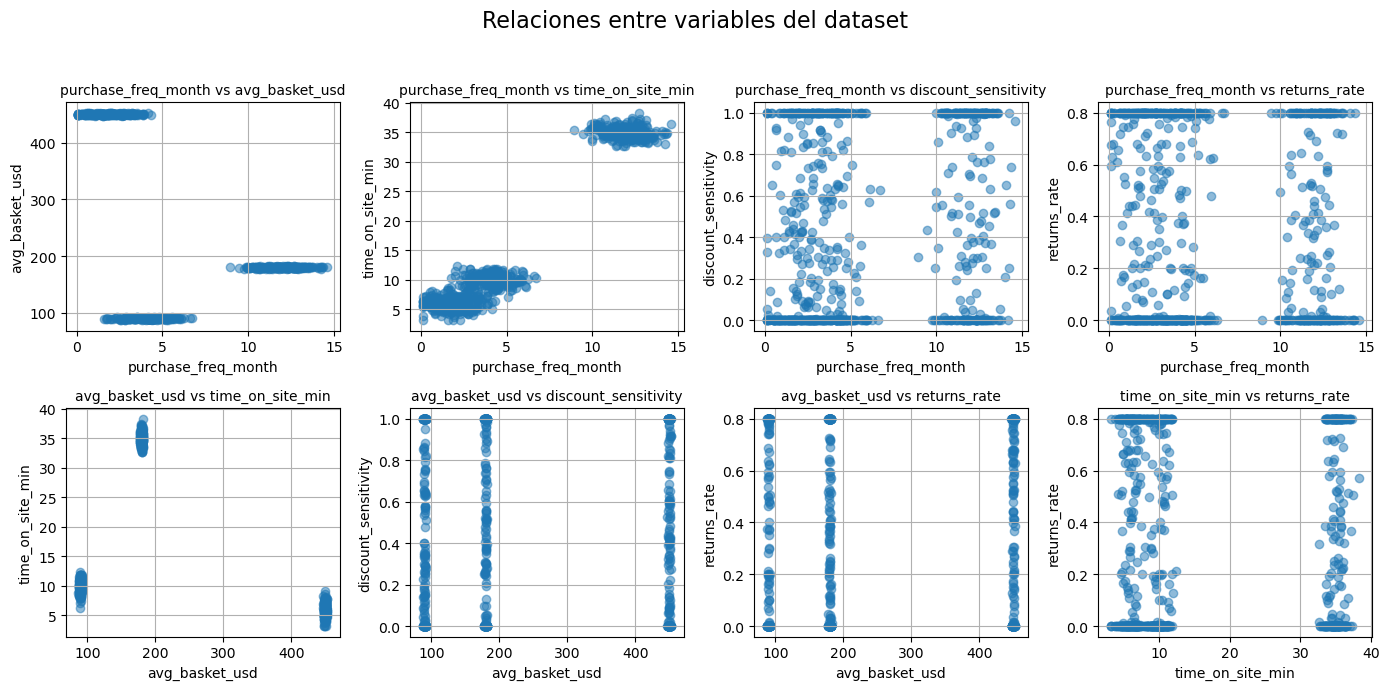

In [5]:
# Previsualizar los datos

fig, axs = plt.subplots(2,4,figsize=(14,7))

vars = [
    "purchase_freq_month",
    "avg_basket_usd",
    "time_on_site_min",
    "discount_sensitivity",
    "returns_rate"]

pairs = [
    (0,1), (0,2), (0,3), (0,4),
    (1,2), (1,3), (1,4), (2,4)]

fig.suptitle("Relaciones entre variables del dataset", fontsize=16)

for ax, (i, j) in zip(axs.flat, pairs):
    ax.scatter(datos_csv_limpios[vars[i]], datos_csv_limpios[vars[j]], alpha=0.5)
    ax.set_title(f"{vars[i]} vs {vars[j]}", fontsize=10)
    ax.set_xlabel(vars[i])
    ax.set_ylabel(vars[j])
    ax.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [6]:
# Escalar datos
# Casi todos necesitan escalars, purchase_freq_month, avg_basket_usd, time_on_site_min, returns_rate	

scaler = StandardScaler()

X_scaled = scaler.fit_transform(datos_csv_limpios)

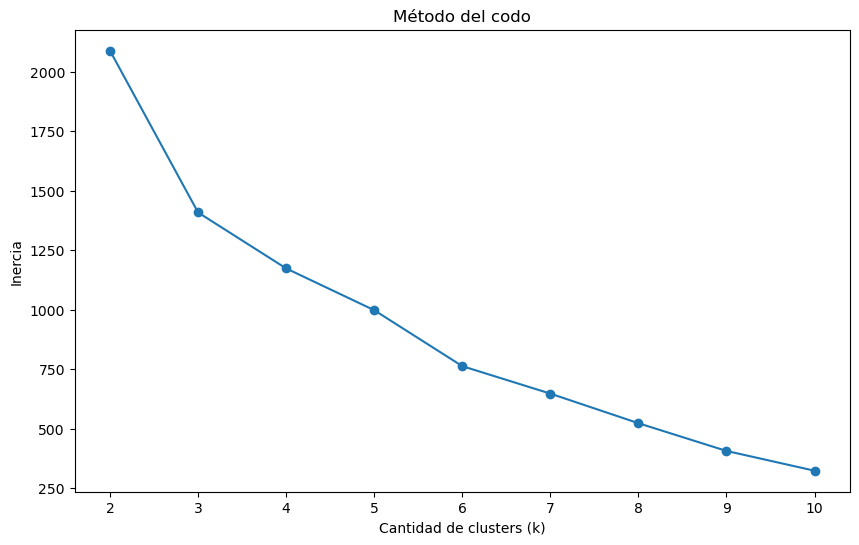

In [7]:
# Metodo del Codo

inercias = []

valores_k = range(2, 11)

for k in valores_k:
    modelo = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42,
        n_init=10
    )

    modelo.fit(X_scaled)

    inercias.append(modelo.inertia_)
    
plt.figure(figsize=(10,6))

plt.plot(valores_k, inercias, marker='o')

plt.xlabel('Cantidad de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del codo')

plt.show()

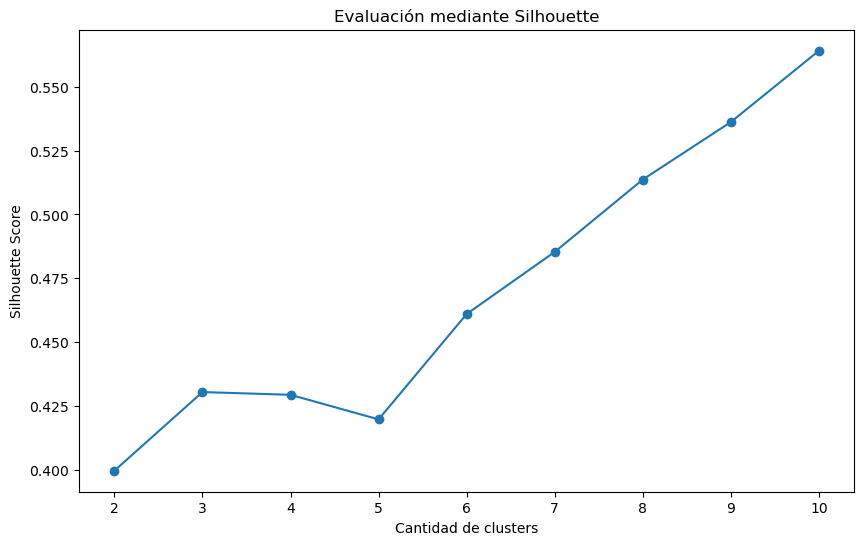

In [8]:
# Silhouette Score

silhouette_scores = []

for k in range(2,11):

    modelo = KMeans(
        n_clusters=k,
        init='k-means++',#se lo acabo de agregar
        random_state=42,
        n_init=10
    )

    labels = modelo.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    silhouette_scores.append(score)

plt.figure(figsize=(10,6))

plt.plot(range(2,11), silhouette_scores, marker='o')

plt.xlabel('Cantidad de clusters')
plt.ylabel('Silhouette Score')
plt.title('Evaluación mediante Silhouette')

plt.show()    


In [9]:
# Cálculo de Método del Codo y Evaluación mediante Silhouette
# es lo mismo que arriba sólo que ya tengo los dos gráficos lado a lado

results = []

for k in range(2,11):
    km = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42,
        n_init=10,
        max_iter=300
    )
    km.fit(X_scaled)

    sil = silhouette_score(
        X_scaled,
        km.labels_
    )

    results.append((k, km.inertia_, sil))



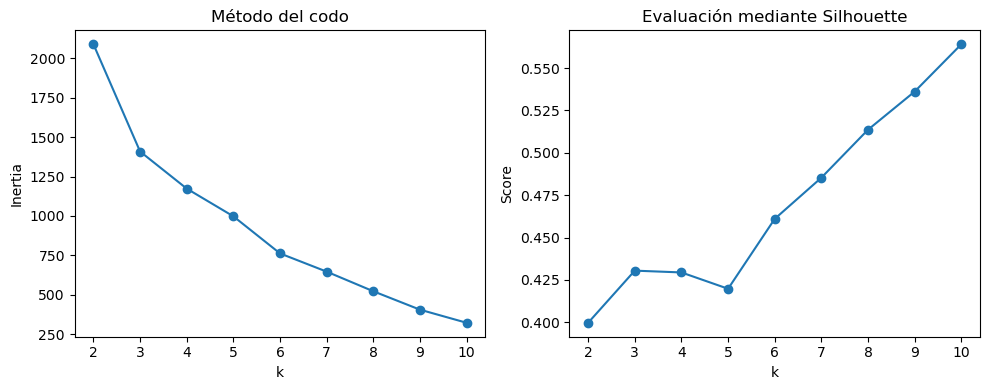

In [10]:
ks = range(2,11)

inertias = [r[1] for r in results]
silhouettes = [r[2] for r in results]

fig, axs = plt.subplots(1,2, figsize=(10,4))

axs[0].plot(ks, inertias, marker='o')
axs[0].set_title("Método del codo")
axs[0].set_xlabel("k")
axs[0].set_ylabel("Inertia")

axs[1].plot(ks, silhouettes, marker='o')
axs[1].set_title("Evaluación mediante Silhouette")
axs[1].set_xlabel("k")
axs[1].set_ylabel("Score")

plt.tight_layout()
plt.show()

In [11]:
# Entrenamiento Kmeans

kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=42
)

kmeans.fit(X_scaled)

,n_clusters,3
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [12]:
clusters = kmeans.labels_

datos_csv_limpios['cluster'] = clusters

datos_csv_limpios.head()

,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,cluster
0,11.152508,181.300834,33.564036,1.000000,0.800000,0
1,12.053451,178.637272,35.432081,0.784974,0.000000,0
2,2.203006,450.185298,7.030757,0.898297,0.000000,1
3,4.233314,89.006342,10.834453,0.000000,0.800000,2
4,1.716799,449.773982,7.254548,0.000000,0.003279,1


In [13]:
# Tamaño de los clusters
pd.Series(kmeans.labels_).value_counts()

1    250
0    230
2    220
Name: count, dtype: int64

In [14]:
# Centroides
centers = scaler.inverse_transform(kmeans.cluster_centers_)

X = datos_csv_limpios[vars]

centroides = pd.DataFrame(centers, columns=X.columns)

print(centroides)

   purchase_freq_month  avg_basket_usd  time_on_site_min  \
0            11.961153      179.999315         35.022131   
1             1.846908      450.123746          5.973739   
2             4.091883       89.957567         10.003793   

   discount_sensitivity  returns_rate  
0              0.541539      0.332461  
1              0.358088      0.375371  
2              0.379465      0.298761  


In [15]:
# Otra forma de ver los Centroides
datos_csv_limpios.groupby("cluster").mean()



,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate
cluster,,,,,
0,11.961153,179.999315,35.022131,0.541539,0.332461
1,1.846908,450.123746,5.973739,0.358088,0.375371
2,4.091883,89.957567,10.003793,0.379465,0.298761


In [16]:
datos_csv_limpios.describe()

,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,cluster
count,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000
mean,5.875724,248.173491,16.784799,0.425083,0.337194,0.985714
std,4.471079,154.904372,12.914111,0.431467,0.356623,0.802230
min,0.100000,86.994100,3.163206,0.000000,0.000000,0.000000
25%,2.278418,90.766945,6.603950,0.000000,0.000000,0.000000
50%,4.134580,180.223799,9.974407,0.296475,0.165559,1.000000
75%,11.214919,449.719033,34.341360,1.000000,0.800000,2.000000
max,14.603388,452.973583,38.348156,1.000000,0.800000,2.000000


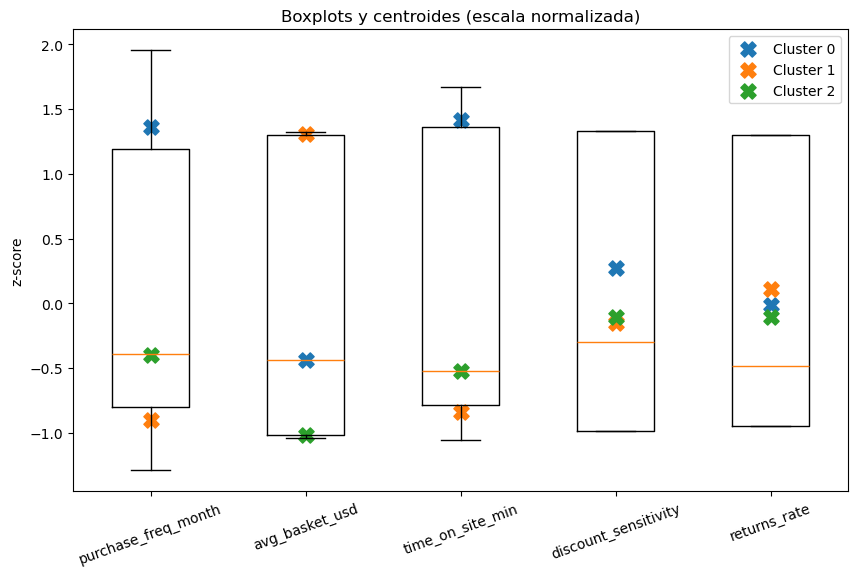

In [17]:
# vamos a superponer boxplot y centroides
# vamos a usar los valores normalizados para que sean comparables en una escala única

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=vars
)

centroides_scaled = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=vars
)

fig, ax = plt.subplots(figsize=(10,6))

ax.boxplot(
    [X_scaled_df[v] for v in vars],
    tick_labels=vars
)

for i in range(len(centroides_scaled)):
    ax.scatter(
        range(1, len(vars)+1),
        centroides_scaled.iloc[i],
        s=120,
        marker='X',
        label=f'Cluster {i}'
    )

ax.set_title("Boxplots y centroides (escala normalizada)")
ax.set_ylabel("z-score")
ax.legend()

plt.xticks(rotation=20)
plt.show()

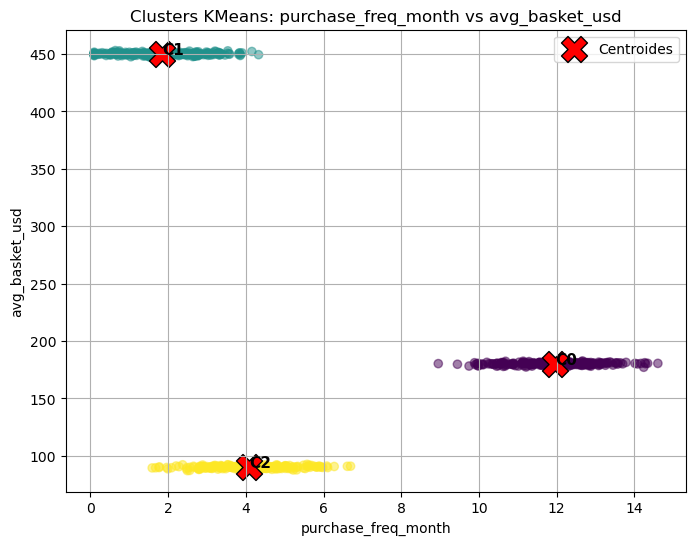

In [18]:
# Vamos a dibujar el scatter plot con los centroides
# Elegir variables 

x_var = vars[0]
y_var = vars[1]

# Reconstruir centroides a escala original
centers = scaler.inverse_transform(
    kmeans.cluster_centers_
)

centroides = pd.DataFrame(
    centers,
    columns=vars
)

plt.figure(figsize=(8,6))

# Datos coloreados por cluster
plt.scatter(
    datos_csv_limpios[x_var],
    datos_csv_limpios[y_var],
    c=kmeans.labels_,
    cmap="viridis",
    alpha=0.5
)

# Centroides
plt.scatter(
    centroides[x_var],
    centroides[y_var],
    s=350,
    marker="X",
    color="red",
    edgecolor="black",
    label="Centroides"
)

# Etiquetas de centroides
for i in range(len(centroides)):
    plt.text(
        centroides.loc[i, x_var],
        centroides.loc[i, y_var],
        f"C{i}",
        fontsize=11,
        fontweight="bold"
    )

plt.xlabel(x_var)
plt.ylabel(y_var)
plt.title(f"Clusters KMeans: {x_var} vs {y_var}")
plt.legend()
plt.grid(True)

plt.show()

In [19]:
# Vamos a probar con k=4
# Entrenamiento Kmeans

kmeans = KMeans(
    n_clusters=4,
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=42
)

kmeans.fit(X_scaled)

clusters = kmeans.labels_

datos_csv_limpios['cluster'] = clusters

# Tamaño de los clusters
pd.Series(kmeans.labels_).value_counts()



0    230
2    220
3    129
1    121
Name: count, dtype: int64

In [20]:
# Centroides
centers = scaler.inverse_transform(kmeans.cluster_centers_)

X = datos_csv_limpios[vars]

centroides = pd.DataFrame(centers, columns=X.columns)

print(centroides)

   purchase_freq_month  avg_basket_usd  time_on_site_min  \
0            11.961153      179.999315         35.022131   
1             1.804860      450.034002          6.066596   
2             4.091883       89.957567         10.003793   
3             1.886348      450.207924          5.886640   

   discount_sensitivity  returns_rate  
0              0.541539      0.332461  
1              0.357851      0.732297  
2              0.379465      0.298761  
3              0.358310      0.040579  


In [21]:
# Otra forma de ver los Centroides
datos_csv_limpios.groupby("cluster").mean()

,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate
cluster,,,,,
0,11.961153,179.999315,35.022131,0.541539,0.332461
1,1.804860,450.034002,6.066596,0.357851,0.732297
2,4.091883,89.957567,10.003793,0.379465,0.298761
3,1.886348,450.207924,5.886640,0.358310,0.040579


In [22]:
datos_csv_limpios.describe()

,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,cluster
count,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000
mean,5.875724,248.173491,16.784799,0.425083,0.337194,1.354286
std,4.471079,154.904372,12.914111,0.431467,0.356623,1.120837
min,0.100000,86.994100,3.163206,0.000000,0.000000,0.000000
25%,2.278418,90.766945,6.603950,0.000000,0.000000,0.000000
50%,4.134580,180.223799,9.974407,0.296475,0.165559,1.000000
75%,11.214919,449.719033,34.341360,1.000000,0.800000,2.000000
max,14.603388,452.973583,38.348156,1.000000,0.800000,3.000000


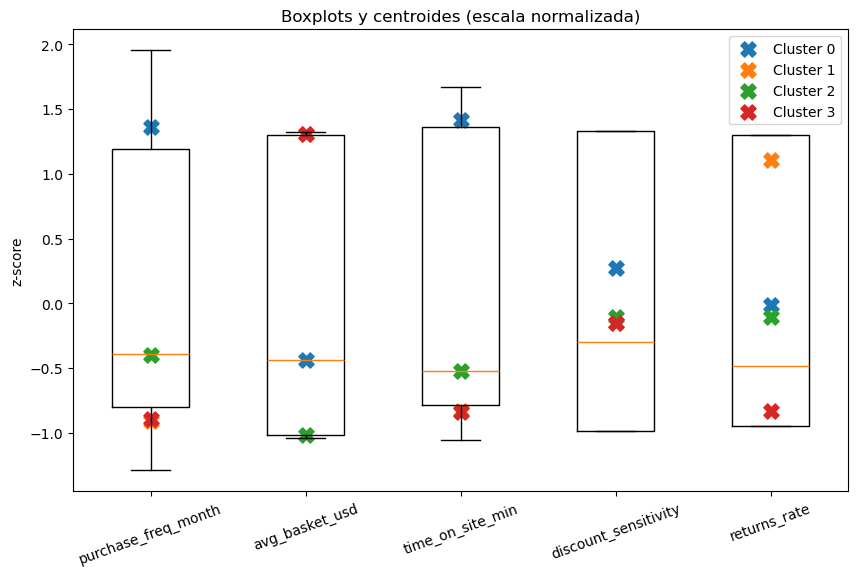

In [23]:
# vamos a superponer boxplot y centroides
# vamos a usar los valores normalizados para que sean comparables en una escala única

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=vars
)

centroides_scaled = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=vars
)

fig, ax = plt.subplots(figsize=(10,6))

ax.boxplot(
    [X_scaled_df[v] for v in vars],
    tick_labels=vars
)

for i in range(len(centroides_scaled)):
    ax.scatter(
        range(1, len(vars)+1),
        centroides_scaled.iloc[i],
        s=120,
        marker='X',
        label=f'Cluster {i}'
    )

ax.set_title("Boxplots y centroides (escala normalizada)")
ax.set_ylabel("z-score")
ax.legend()

plt.xticks(rotation=20)
plt.show()

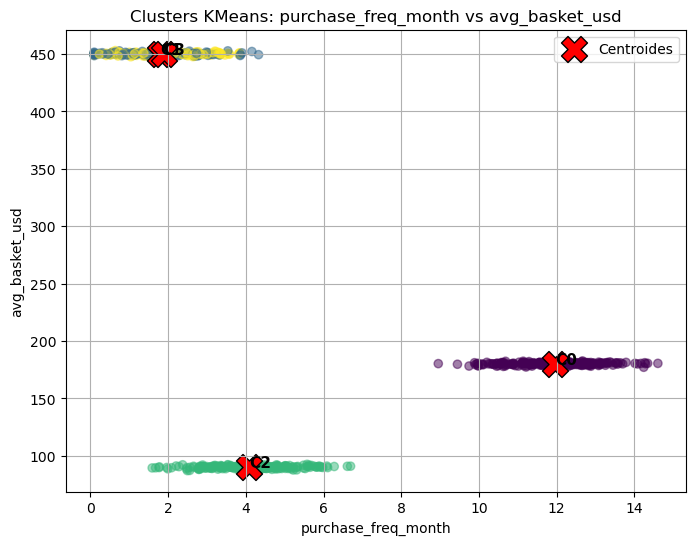

In [24]:
# Vamos a dibujar el scatter plot con los centroides
# Elegir variables 

x_var = vars[0]
y_var = vars[1]

# Reconstruir centroides a escala original
centers = scaler.inverse_transform(
    kmeans.cluster_centers_
)

centroides = pd.DataFrame(
    centers,
    columns=vars
)

plt.figure(figsize=(8,6))

# Datos coloreados por cluster
plt.scatter(
    datos_csv_limpios[x_var],
    datos_csv_limpios[y_var],
    c=kmeans.labels_,
    cmap="viridis",
    alpha=0.5
)

# Centroides
plt.scatter(
    centroides[x_var],
    centroides[y_var],
    s=350,
    marker="X",
    color="red",
    edgecolor="black",
    label="Centroides"
)

# Etiquetas de centroides
for i in range(len(centroides)):
    plt.text(
        centroides.loc[i, x_var],
        centroides.loc[i, y_var],
        f"C{i}",
        fontsize=11,
        fontweight="bold"
    )

plt.xlabel(x_var)
plt.ylabel(y_var)
plt.title(f"Clusters KMeans: {x_var} vs {y_var}")
plt.legend()
plt.grid(True)

plt.show()

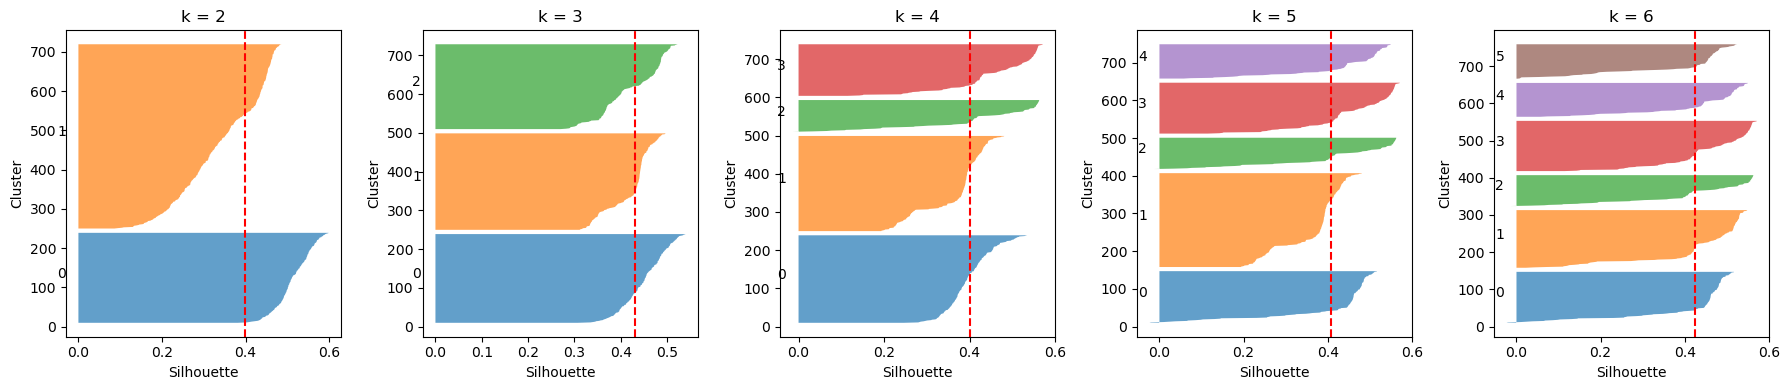

In [27]:
range_n_clusters = range(2,7)

fig, axs = plt.subplots(
    1,
    len(range_n_clusters),
    figsize=(18,4)
)

for ax, k in zip(axs, range_n_clusters):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )
    labels = kmeans.fit_predict(X_scaled)

    silhouette_avg = silhouette_score(
        X_scaled,
        labels
    )

    sample_silhouette_values = silhouette_samples(
        X_scaled,
        labels
    )

    y_lower = 10

    for i in range(k):

        ith_cluster_silhouette_values = (
            sample_silhouette_values[labels == i]
        )

        ith_cluster_silhouette_values.sort()

        size_cluster_i = len(
            ith_cluster_silhouette_values
        )

        y_upper = y_lower + size_cluster_i

        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            alpha=0.7
        )

        ax.text(
            -0.05,
            y_lower + 0.5 * size_cluster_i,
            str(i)
        )

        y_lower = y_upper + 10

    ax.axvline(
        x=silhouette_avg,
        color="red",
        linestyle="--"
    )

    ax.set_title(f"k = {k}")
    ax.set_xlabel("Silhouette")
    ax.set_ylabel("Cluster")

plt.tight_layout()
plt.show()